Module 1: 基石算子——代码实战

> 从广播机制到激活函数，从归一化到手算梯度——用代码验证每一个概念。

## 0. 环境准备

导入所有需要的库。`torch` 做张量运算，`numpy` 辅助数据处理，`matplotlib` 画图。

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (10, 5)
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print("Ready!")

PyTorch: 2.6.0+cu118
NumPy: 1.26.4
Ready!


---
## 1. 数学运算

### 1.1 七种基本二元运算

两个张量逐元素做运算。Add 做残差连接，Mul 做门控，Pow 做 RoPE 频率。

In [71]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
print(f"a = {a.tolist()}")
print(f"b = {b.tolist()}")
print()
print(f"a + b  = {(a + b).tolist()}     # Add: 残差连接")
print(f"a - b  = {(a - b).tolist()}     # Sub: 差值")
print(f"a * b  = {(a * b).tolist()}     # Mul: 门控 gate*value")
print(f"a / b  = {(a / b).tolist()}     # Div: 缩放")
print(f"a ** 2 = {(a ** 2).tolist()}   # Pow: RoPE 频率")
print(f"max(a,b) = {torch.maximum(a, b).tolist()}   # Max: 逐元素取最大")

a = [1.0, 2.0, 3.0]
b = [4.0, 5.0, 6.0]

a + b  = [5.0, 7.0, 9.0]     # Add: 残差连接
a - b  = [-3.0, -3.0, -3.0]     # Sub: 差值
a * b  = [4.0, 10.0, 18.0]     # Mul: 门控 gate*value
a / b  = [0.25, 0.4000000059604645, 0.5]     # Div: 缩放
a ** 2 = [1.0, 4.0, 9.0]   # Pow: RoPE 频率
max(a,b) = [4.0, 5.0, 6.0]   # Max: 逐元素取最大


### 1.2 广播机制——逐维度对齐

规则: 从后往前比较，每维要么相等，要么其中一个为 1。

**能广播的例子:**

In [72]:
print("="*50)
print("能广播的例子:")
print()
x = torch.ones(3, 1, 4)
y = torch.ones(1, 5, 4) * 2
z = x + y
print(f"[3,1,4] + [1,5,4] -> shape={z.shape} (预期 [3,5,4])")
x = torch.ones(2, 3)
y = torch.tensor([10.0, 20.0, 30.0])
z = x + y
print(f"[2,3] + [3] -> shape={z.shape} (预期 [2,3])")
print("z =")
print(z)
print()
gamma = torch.tensor([1.0, 2.0, 3.0])
x = torch.ones(2, 3, 4, 4)
result = x * gamma.view(1, 3, 1, 1)
print(f"BN 风格广播: gamma[3]*x[2,3,4,4] -> shape={result.shape}")
print(f"  ch0 all={result[0,0,0,0]:.0f}, ch1 all={result[0,1,0,0]:.0f}, ch2 all={result[0,2,0,0]:.0f}")

能广播的例子:

[3,1,4] + [1,5,4] -> shape=torch.Size([3, 5, 4]) (预期 [3,5,4])
[2,3] + [3] -> shape=torch.Size([2, 3]) (预期 [2,3])
z =
tensor([[11., 21., 31.],
        [11., 21., 31.]])

BN 风格广播: gamma[3]*x[2,3,4,4] -> shape=torch.Size([2, 3, 4, 4])
  ch0 all=1, ch1 all=2, ch2 all=3


**不能广播的例子:**

In [73]:
print("="*50)
print("不能广播的例子:")
print()
try:
    x = torch.ones(3, 4); y = torch.ones(2, 4); z = x + y
except RuntimeError:
    print("[3,4] + [2,4] -> 轴0: 3 vs 2, 都不为1, 无法广播!")
    print()
try:
    x = torch.ones(2, 3, 4); y = torch.ones(5, 4); z = x + y
except RuntimeError:
    print("[2,3,4] + [5,4] -> 轴1: 3 vs 5, 都不为1!")

不能广播的例子:

[3,4] + [2,4] -> 轴0: 3 vs 2, 都不为1, 无法广播!

[2,3,4] + [5,4] -> 轴1: 3 vs 5, 都不为1!


### 1.3 归约运算

归约沿指定维度将多个值聚合为一个。GlobalAvgPool = Mean 归约, Softmax 分母 = Sum 归约。

In [74]:
x = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0]])
print(f"原始 [{x.shape[0]}x{x.shape[1]}]:")
print(x)
print()
print(f"Sum(dim=1)  = {x.sum(dim=1).tolist()}       # 每行求和")
print(f"Mean(dim=1) = {x.mean(dim=1).tolist()}      # 每行平均 (GAP)")
print(f"Max(dim=1)  = {x.max(dim=1).values.tolist()} # 每行最大值")
print()
print("全归约:")
print(f"  全局 Sum  = {x.sum().item()}")
print(f"  全局 Mean = {x.mean().item():.4f}")

原始 [2x4]:
tensor([[1., 2., 3., 4.],
        [5., 6., 7., 8.]])

Sum(dim=1)  = [10.0, 26.0]       # 每行求和
Mean(dim=1) = [2.5, 6.5]      # 每行平均 (GAP)
Max(dim=1)  = [4.0, 8.0] # 每行最大值

全归约:
  全局 Sum  = 36.0
  全局 Mean = 4.5000


---
## 2. 激活函数

激活函数 = 神经网络的灵魂。没有它，100层 = 1层。注意观察负值区: ReLU 归零, GELU/Swish 保留信号——这就是死亡 ReLU 的根源。

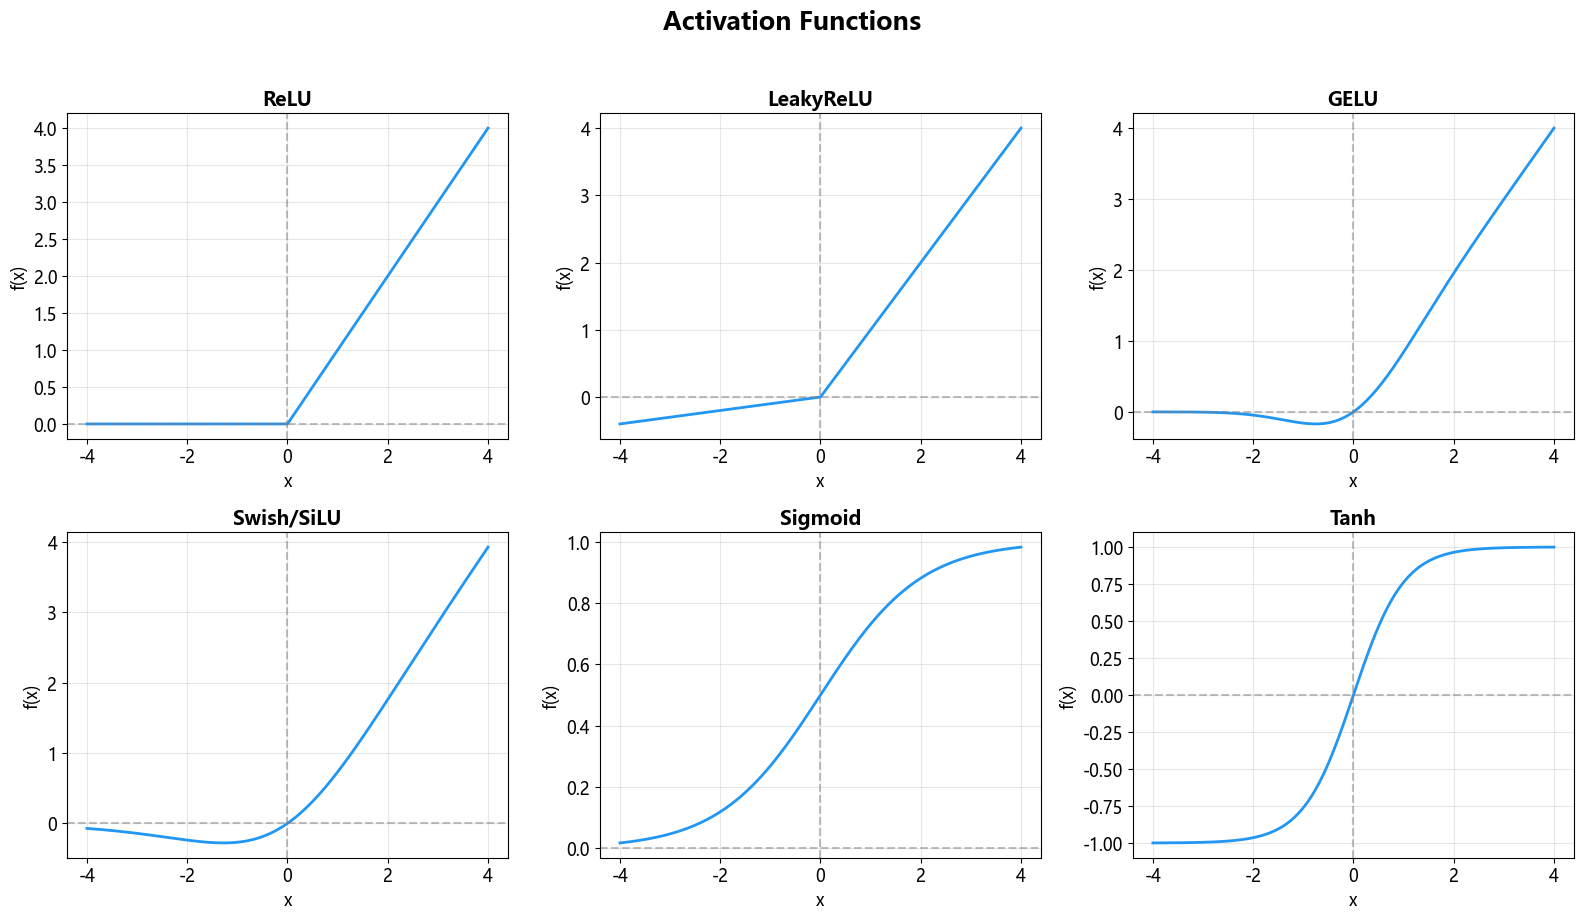

In [75]:
x = torch.linspace(-4, 4, 500)
acts = {"ReLU":F.relu(x), "LeakyReLU":F.leaky_relu(x,0.1),
        "GELU":F.gelu(x), "Swish/SiLU":F.silu(x),
        "Sigmoid":torch.sigmoid(x), "Tanh":torch.tanh(x)}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, y) in zip(axes.flatten(), acts.items()):
    ax.plot(x.numpy(), y.numpy(), lw=2, color="#2196F3")
    ax.axhline(y=0, color="gray", ls="--", alpha=0.5)
    ax.axvline(x=0, color="gray", ls="--", alpha=0.5)
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.grid(True, alpha=0.3)
plt.suptitle("Activation Functions", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

**ReLU vs GELU vs Swish 同图对比——聚焦负值区:**

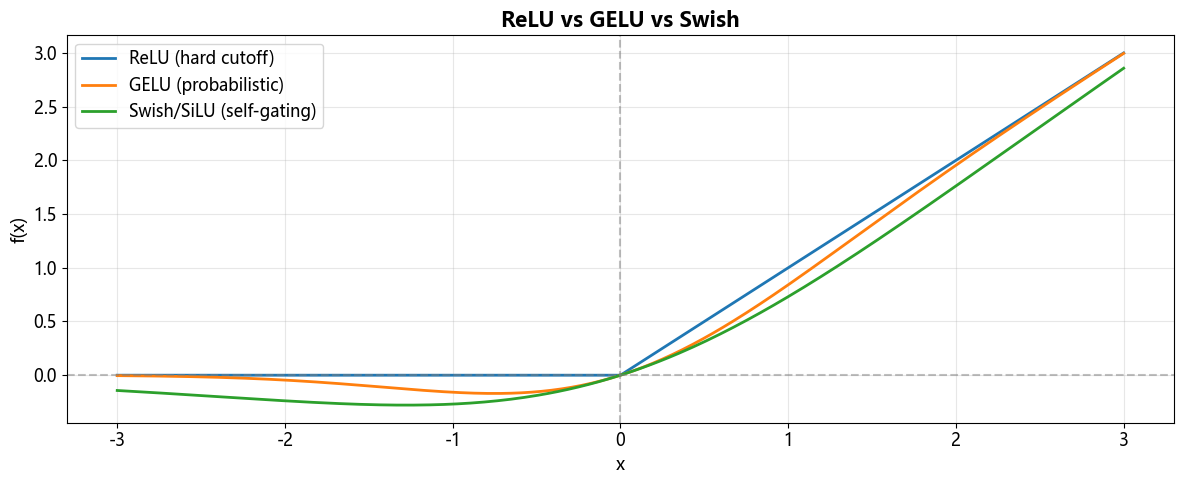

负值区行为对比:
  x=-3: ReLU= 0.000, GELU=-0.004, Swish=-0.142
  x=-1: ReLU= 0.000, GELU=-0.159, Swish=-0.269
  x= 0: ReLU= 0.000, GELU= 0.000, Swish= 0.000

关键: x=-3 时 ReLU=0 (梯度=0!), 但 Swish=-0.14 (仍有梯度)


In [76]:
x = torch.linspace(-3, 3, 300)
plt.figure(figsize=(12, 5))
plt.plot(x.numpy(), F.relu(x).numpy(), lw=2, label="ReLU (hard cutoff)")
plt.plot(x.numpy(), F.gelu(x).numpy(), lw=2, label="GELU (probabilistic)")
plt.plot(x.numpy(), F.silu(x).numpy(), lw=2, label="Swish/SiLU (self-gating)")
plt.axhline(y=0, color="gray", ls="--", alpha=0.5)
plt.axvline(x=0, color="gray", ls="--", alpha=0.5)
plt.xlabel("x", fontsize=13); plt.ylabel("f(x)", fontsize=13)
plt.title("ReLU vs GELU vs Swish", fontsize=15, fontweight="bold")
plt.legend(fontsize=12, loc="upper left"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("负值区行为对比:")
for val in [-3, -1, 0]:
    r = F.relu(torch.tensor(float(val))).item()
    g = F.gelu(torch.tensor(float(val))).item()
    s = F.silu(torch.tensor(float(val))).item()
    print(f"  x={val:2d}: ReLU={r:6.3f}, GELU={g:6.3f}, Swish={s:6.3f}")
print()
print("关键: x=-3 时 ReLU=0 (梯度=0!), 但 Swish=-0.14 (仍有梯度)")

### 2.1 Sigmoid vs Softmax

Sigmoid: 独立判断 (可以多个高概率)。Softmax: 联合决策 (概率和=1, 只能选一个)。

原始值: [2.0, 1.0, 0.5, -1.0]
Sigmoid: ['0.881', '0.731', '0.622', '0.269']
  -> 各值在(0,1), 总和=2.503 (不是1!)
Softmax: ['0.609', '0.224', '0.136', '0.030']
  -> 各值在(0,1), 总和=1.000 (一定是1)



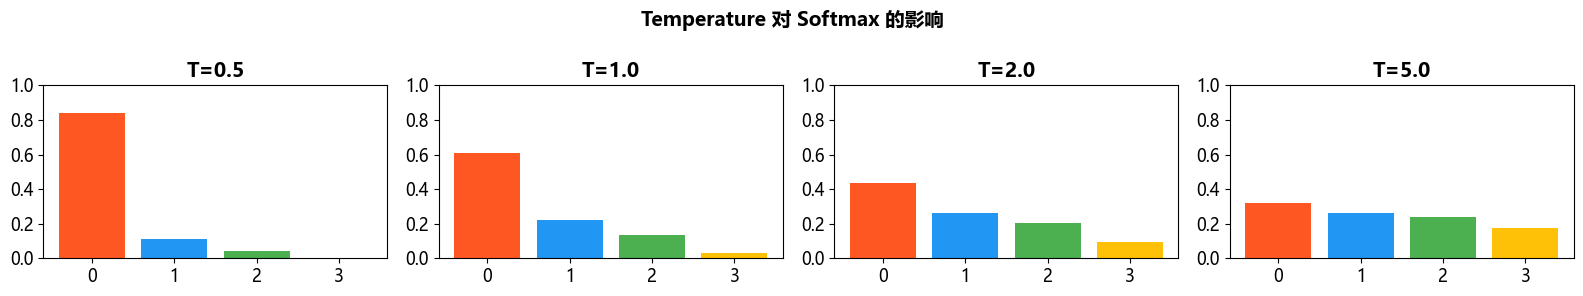

T<1: 更尖锐 | T=1: 原始 | T>1: 更平滑


In [77]:
logits = torch.tensor([2.0, 1.0, 0.5, -1.0])
sig = torch.sigmoid(logits)
print(f"原始值: {logits.tolist()}")
print(f"Sigmoid: {[f'{x:.3f}' for x in sig.tolist()]}")
print(f"  -> 各值在(0,1), 总和={sig.sum():.3f} (不是1!)")
sfm = F.softmax(logits, dim=0)
print(f"Softmax: {[f'{x:.3f}' for x in sfm.tolist()]}")
print(f"  -> 各值在(0,1), 总和={sfm.sum():.3f} (一定是1)")
print()
temps = [0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = ["#FF5722","#2196F3","#4CAF50","#FFC107"]
for ax, T in zip(axes, temps):
    probs = F.softmax(logits / T, dim=0)
    ax.bar(range(4), probs.numpy(), color=colors)
    ax.set_title(f"T={T}", fontweight="bold"); ax.set_ylim(0, 1)
plt.suptitle("Temperature 对 Softmax 的影响", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print("T<1: 更尖锐 | T=1: 原始 | T>1: 更平滑")

### 2.2 SwiGLU——现代 LLM MLP 的核心

SwiGLU = Swish(x.W_gate) * (x.W_up) . W_down。gate 产生门控信号，up 携带信息，相乘 = 选择性放行。中间维度 3x hidden (非 4x), 因 SwiGLU 有 3 个权重矩阵。

In [78]:
hd, inter = 8, 24
x = torch.randn(1, hd)
Wg, Wu, Wd = torch.randn(hd, inter), torch.randn(hd, inter), torch.randn(inter, hd)
gate = F.silu(x @ Wg)
up = x @ Wu
gated = gate * up
output = gated @ Wd
print(f"Input:  {x.shape}")
print(f"gate:   Swish(x.Wg) -> {gate.shape}    (门控信号)")
print(f"up:     x.Wu        -> {up.shape}      (信息流)")
print(f"gated:  gate * up   -> {gated.shape}    (选择性放行!)")
print(f"output: gated.Wd    -> {output.shape}   (最终输出)")
print(f"\n门控统计: min={gate.min():.2f}, max={gate.max():.2f}, mean={gate.mean():.2f}")
pct = ((gate > 0.01) & (gate < 0.99)).float().mean() * 100
print(f"{pct:.0f}% 处于部分门控状态 (0.01~0.99)")

Input:  torch.Size([1, 8])
gate:   Swish(x.Wg) -> torch.Size([1, 24])    (门控信号)
up:     x.Wu        -> torch.Size([1, 24])      (信息流)
gated:  gate * up   -> torch.Size([1, 24])    (选择性放行!)
output: gated.Wd    -> torch.Size([1, 8])   (最终输出)

门控统计: min=-0.28, max=6.03, mean=0.61
33% 处于部分门控状态 (0.01~0.99)


---
## 3. 归一化——手写 BN / LN / RMSNorm

- BatchNorm: 跨 (N,H,W) 统计, CNN 专用
- LayerNorm: 跨 (C,H,W) 统计, Transformer 专用
- RMSNorm: LN 精简版, 去均值减法+beta, 省30%计算, LLM 标配

In [ ]:
def my_bn(x, g, b, eps=1e-5):
    """BatchNorm: 跨 (N,H,W) 统计, 每通道独立"""
    m = x.mean(dim=(0,2,3), keepdim=True)
    v = x.var(dim=(0,2,3), keepdim=True, unbiased=False)
    return g.view(1,-1,1,1)*(x-m)/torch.sqrt(v+eps)+b.view(1,-1,1,1)

def my_ln(x, g, b, eps=1e-5):
    """LayerNorm: 跨最后一维统计 (Transformer 标准形状 [B,L,D])"""
    m = x.mean(dim=-1, keepdim=True)
    v = x.var(dim=-1, keepdim=True, unbiased=False)
    return g*(x-m)/torch.sqrt(v+eps)+b

def my_rms(x, g, eps=1e-6):
    """RMSNorm: 只用均方根缩放, 无均值减法, 无beta"""
    r = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True)+eps)
    return x/r*g

# ---- Test BatchNorm (4D CNN形状) ----
x4d = torch.randn(2,3,4,4)
print(f"BN  vs PyTorch: {(my_bn(x4d,torch.ones(3),torch.zeros(3))-F.batch_norm(x4d,torch.zeros(3),torch.ones(3),training=True)).abs().max():.2e}")

# ---- Test LayerNorm & RMSNorm (3D Transformer形状) ----
x3d = torch.randn(2, 10, 64)      # [batch, seq_len, hidden_dim]
g64, b64 = torch.ones(64), torch.zeros(64)

# LayerNorm: 对最后一维(64)做归一化
ln_my = my_ln(x3d, g64, b64)
ln_pt = F.layer_norm(x3d, [64], weight=g64, bias=b64)
print(f"LN  vs PyTorch: {(ln_my-ln_pt).abs().max():.2e}")

# RMSNorm
r = my_rms(x3d, torch.ones(64))
print(f"RMS  output: {r.shape}, mean={r.mean():.4f}")
print("All verified! error < 1e-6")

**可视化: 归一化前后分布**

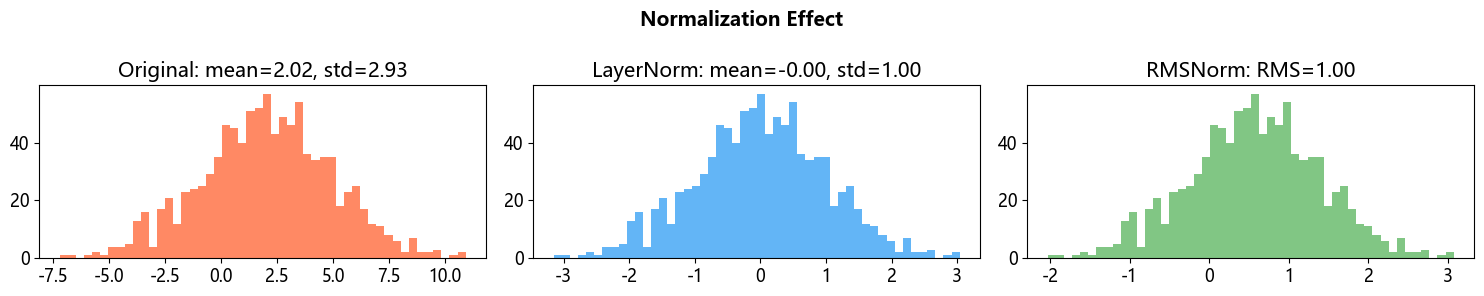

In [80]:
xr = torch.randn(1000)*3+2
xl = (xr-xr.mean())/xr.std()
xrm = xr/torch.sqrt(torch.mean(xr**2))
fig, axes = plt.subplots(1,3,figsize=(15,3))
axes[0].hist(xr.numpy(),50,color="#FF5722",alpha=0.7)
axes[0].set_title(f"Original: mean={xr.mean():.2f}, std={xr.std():.2f}")
axes[1].hist(xl.numpy(),50,color="#2196F3",alpha=0.7)
axes[1].set_title(f"LayerNorm: mean={xl.mean():.2f}, std={xl.std():.2f}")
axes[2].hist(xrm.numpy(),50,color="#4CAF50",alpha=0.7)
axes[2].set_title(f"RMSNorm: RMS={torch.sqrt(torch.mean(xrm**2)):.2f}")
plt.suptitle("Normalization Effect",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.show()

---
## 4. 梯度与反向传播——手算验证

手动 SGD: Loss = (wx-target)^2, 梯度 = 2(wx-target)*x。和 PyTorch autograd 对比验证。

In [81]:
w = torch.tensor([0.0]); x = torch.tensor([2.0]); tgt = torch.tensor([3.0]); lr = 0.1
hw, hl = [], []
print("手动 SGD (手算梯度):")
print(f"  Init: w={w.item():.4f}, optimal w={tgt.item()/x.item():.1f}")
print()
for s in range(5):
    yp = w*x; loss = (yp-tgt)**2; grad = 2*(yp-tgt)*x
    w = w-lr*grad; hw.append(w.item()); hl.append(loss.item())
    print(f"  Step{s+1}: w={w.item():.4f}, loss={loss.item():.4f}, grad={grad.item():.4f}")
print(f"\nConverged: w={w.item():.4f} (optimal 1.5)")

手动 SGD (手算梯度):
  Init: w=0.0000, optimal w=1.5

  Step1: w=1.2000, loss=9.0000, grad=-12.0000
  Step2: w=1.4400, loss=0.3600, grad=-2.4000
  Step3: w=1.4880, loss=0.0144, grad=-0.4800
  Step4: w=1.4976, loss=0.0006, grad=-0.0960
  Step5: w=1.4995, loss=0.0000, grad=-0.0192

Converged: w=1.4995 (optimal 1.5)


PyTorch autograd:
  Step1: w=1.2000, loss=9.0000
  Step2: w=1.4400, loss=0.3600
  Step3: w=1.4880, loss=0.0144
  Step4: w=1.4976, loss=0.0006
  Step5: w=1.4995, loss=0.0000


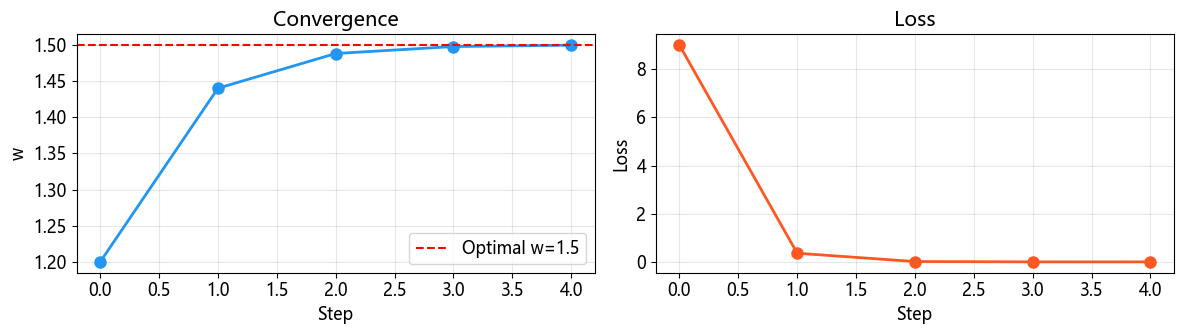

Hand-calc matches autograd!


In [82]:
w2 = torch.tensor([0.0], requires_grad=True)
opt = torch.optim.SGD([w2], lr=0.1)
print("PyTorch autograd:")
for s in range(5):
    loss = (w2*x-tgt)**2; opt.zero_grad(); loss.backward(); opt.step()
    print(f"  Step{s+1}: w={w2.item():.4f}, loss={loss.item():.4f}")
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,3.5))
ax1.plot(hw,"o-",lw=2,color="#2196F3",markersize=8)
ax1.axhline(y=1.5,color="red",ls="--",label="Optimal w=1.5")
ax1.set_xlabel("Step"); ax1.set_ylabel("w"); ax1.set_title("Convergence")
ax1.legend(); ax1.grid(True,alpha=0.3)
ax2.plot(hl,"o-",lw=2,color="#FF5722",markersize=8)
ax2.set_xlabel("Step"); ax2.set_ylabel("Loss"); ax2.set_title("Loss")
ax2.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()
print("Hand-calc matches autograd!")

### 4.1 死亡 ReLU 实验

输入全负时，ReLU 梯度消失。Swish 保留微小梯度，神经元不死。

In [ ]:
torch.manual_seed(42)
class TN(nn.Module):
    def __init__(self, act):
        super().__init__()
        self.f1=nn.Linear(10,10); self.f2=nn.Linear(10,10); self.act=act
    def forward(self,x):
        x=self.act(self.f1(x)); return self.act(self.f2(x)).sum()

# 确保输入全是负数: 取绝对值再取负
x = -torch.abs(torch.randn(1,10))
print(f"Input range: [{x.min():.2f}, {x.max():.2f}] -- truly all negative!")
print()

for name, act in [("ReLU",nn.ReLU()),("Swish",nn.SiLU())]:
    m=TN(act); m(x).backward(); gn=m.f1.weight.grad.norm().item()
    print(f"{name}: fc1 grad norm = {gn:.6f}")
    print(f"  -> {'DEAD! Cannot learn!' if gn==0 else 'Alive! Can learn'}")
    print()

---
## 5. Roofline Model

计算强度 = FLOPs / Bytes。A100拐点~150。B=1 memory-bound, B=512 compute-bound。

In [84]:
def flops(M,N,K): return 2*M*N*K
def mem(M,N,K,b=4): return (M*K+K*N+M*N)*b
def ai(M,N,K,b=4): return flops(M,N,K)/mem(M,N,K,b)
print("Qwen3 Q-proj [B,1024]x[1024,2048] (FP16):")
print(f"  {'B':<8} {'MFLOPs':<10} {'MB':<10} {'AI':<8} {'Type'}")
for B in [1,4,32,256,512]:
    a=ai(B,2048,1024,2)
    bn="Compute-bound" if a>150 else "Memory-bound"
    print(f"  {B:<8} {flops(B,2048,1024)/1e6:>8.1f} {mem(B,2048,1024,2)/1e6:>8.1f} {a:>6.1f}   {bn}")
print("\nA100 knee ~150 FLOPs/Byte")
print("Decode(B=1): Memory-bound | Prefill(B=512): Compute-bound")

Qwen3 Q-proj [B,1024]x[1024,2048] (FP16):
  B        MFLOPs     MB         AI       Type
  1             4.2      4.2    1.0   Memory-bound
  4            16.8      4.2    4.0   Memory-bound
  32          134.2      4.4   30.6   Memory-bound
  256        1073.7      5.8  186.2   Compute-bound
  512        2147.5      7.3  292.6   Compute-bound

A100 knee ~150 FLOPs/Byte
Decode(B=1): Memory-bound | Prefill(B=512): Compute-bound


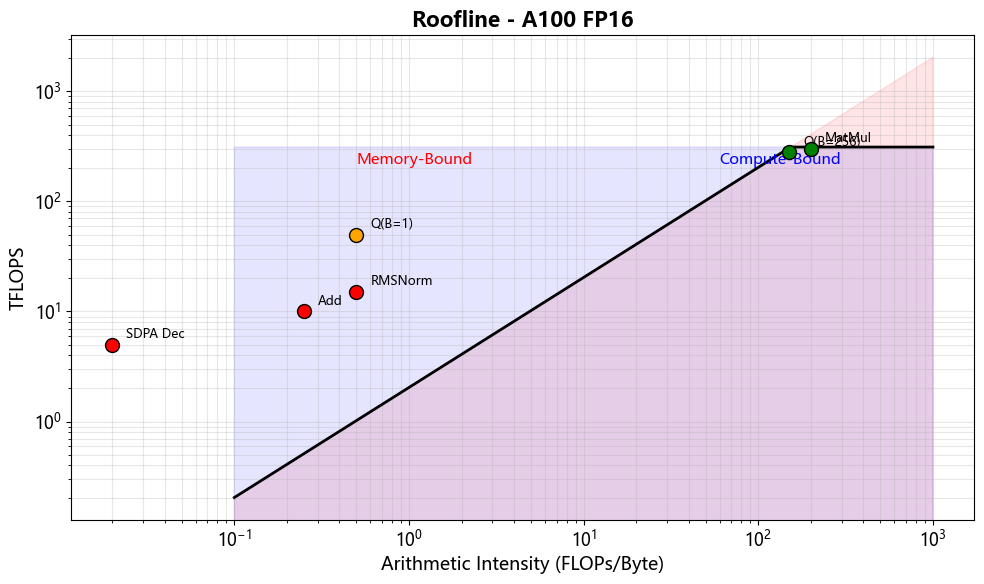

In [85]:
fig,ax=plt.subplots(figsize=(10,6))
ai_r=np.logspace(-1,3,1000)
ax.loglog(ai_r,np.minimum(np.full_like(ai_r,312),2.039*ai_r),"k-",lw=2)
ax.fill_between(ai_r,2.039*ai_r,alpha=0.1,color="red")
ax.fill_between(ai_r,np.full_like(ai_r,312),alpha=0.1,color="blue")
ops={"Add":(0.25,10,"red"),"RMSNorm":(0.5,15,"red"),"Q(B=1)":(0.5,50,"orange"),"SDPA Dec":(0.02,5,"red"),"Q(B=256)":(150,280,"green"),"MatMul":(200,300,"green")}
for n,(a,p,c) in ops.items():
    ax.scatter([a],[p],s=100,c=c,edgecolors="black",zorder=10)
    ax.annotate(n,(a,p),textcoords="offset points",xytext=(10,5),fontsize=9)
ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)",fontsize=13)
ax.set_ylabel("TFLOPS",fontsize=13)
ax.set_title("Roofline - A100 FP16",fontsize=15,fontweight="bold")
ax.text(0.5,220,"Memory-Bound",fontsize=11,color="red")
ax.text(60,220,"Compute-Bound",fontsize=11,color="blue")
ax.grid(True,alpha=0.3,which="both"); plt.tight_layout(); plt.show()

---
## 6. 优化器对比

不良条件函数 f(w1,w2)=w1^2+10w2^2。SGD震荡，Momentum平滑，Adam自适应每参数学习率。

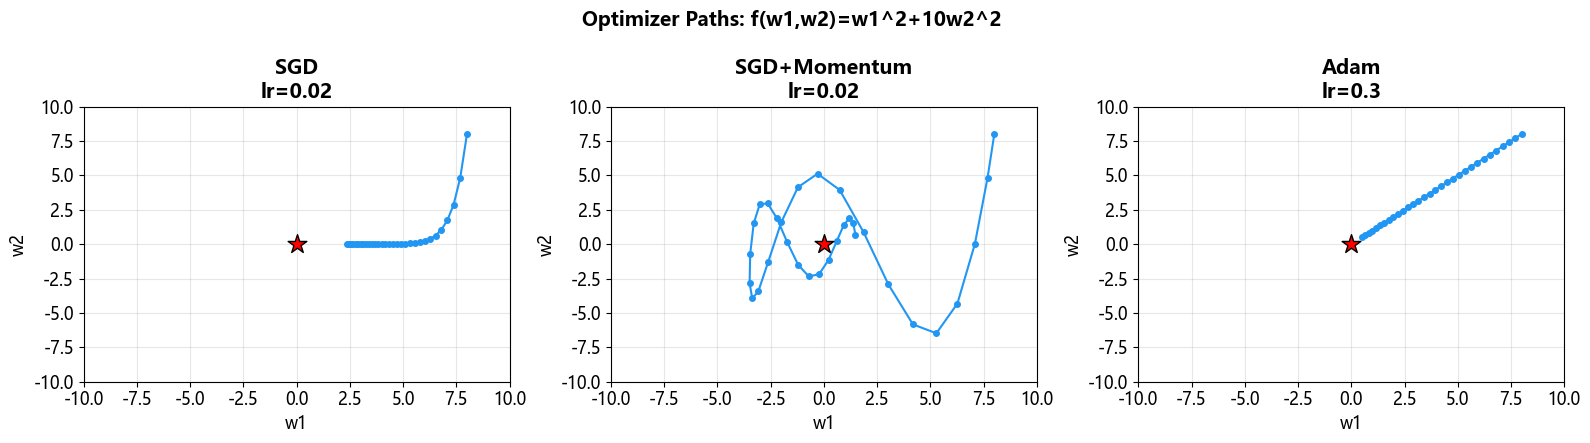

SGD: oscillates | Momentum: smoother | Adam: fastest


In [86]:
def f(w1,w2): return w1**2+10*w2**2
def train(cls,lr,steps=30):
    w=torch.tensor([8.,8.],requires_grad=True)
    opt=cls([w],lr=lr)
    p=[w.detach().clone().numpy()]
    for _ in range(steps):
        opt.zero_grad(); f(w[0],w[1]).backward(); opt.step()
        p.append(w.detach().clone().numpy())
    return np.array(p)
fig,axes=plt.subplots(1,3,figsize=(16,4.5))
cfgs=[("SGD",torch.optim.SGD,0.02),("SGD+Momentum",lambda p,lr:torch.optim.SGD(p,lr=lr,momentum=0.9),0.02),("Adam",torch.optim.Adam,0.3)]
for ax,(nm,cls,lr) in zip(axes,cfgs):
    p=train(cls,lr,30)
    ax.plot(p[:,0],p[:,1],"o-",ms=4,lw=1.5,color="#2196F3")
    ax.scatter([0],[0],s=200,marker="*",color="red",zorder=10,edgecolors="black")
    ax.set_xlim(-10,10); ax.set_ylim(-10,10)
    ax.set_xlabel("w1"); ax.set_ylabel("w2")
    ax.set_title(nm + "\n" + f"lr={lr}",fontweight="bold")
    ax.grid(True,alpha=0.3)
plt.suptitle("Optimizer Paths: f(w1,w2)=w1^2+10w2^2",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.show()
print("SGD: oscillates | Momentum: smoother | Adam: fastest")

---
## 7. 学习率调度

Warmup + Cosine = LLM 训练标配。前 N 步线性增长防梯度爆炸，后余弦衰减精细收敛。

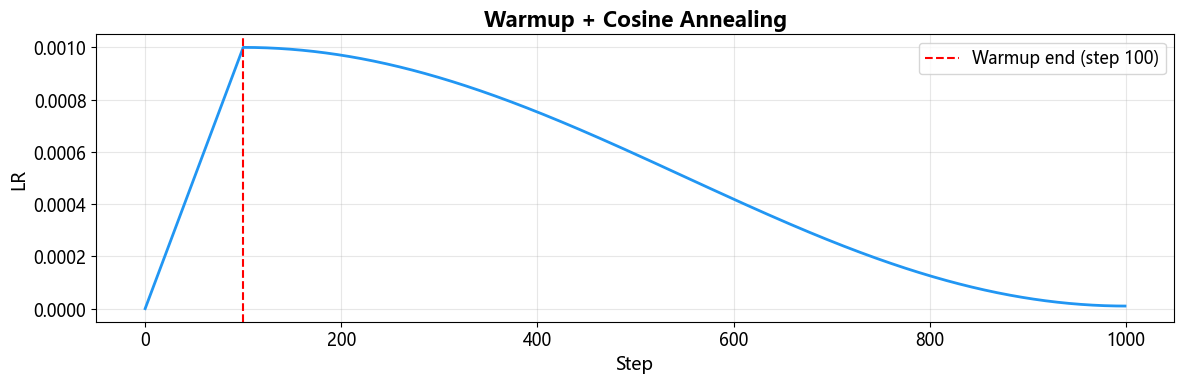

Warmup: 前100步 lr 线性增长
Cosine: 后900步余弦衰减


In [87]:
def wcos(step,warm,tot,lrmax=1e-3,lrmin=1e-5):
    if step<warm: return lrmax*step/warm
    p=(step-warm)/(tot-warm)
    return lrmin+0.5*(lrmax-lrmin)*(1+np.cos(np.pi*p))
lrs=[wcos(s,100,1000) for s in range(1000)]
plt.figure(figsize=(12,4))
plt.plot(lrs,lw=2,color="#2196F3")
plt.axvline(x=100,color="red",ls="--",label="Warmup end (step 100)")
plt.xlabel("Step",fontsize=13); plt.ylabel("LR",fontsize=13)
plt.title("Warmup + Cosine Annealing",fontsize=15,fontweight="bold")
plt.legend(fontsize=12); plt.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()
print("Warmup: 前100步 lr 线性增长")
print("Cosine: 后900步余弦衰减")

---
## 8. SIMD——一次处理多个

Python loop (标量) vs NumPy 向量化 (SIMD)。AVX-512 一次16个FP32, GPU warp 32线程并行。

In [88]:
import time
N=10_000_000
a=np.random.randn(N).astype(np.float32)
b=np.random.randn(N).astype(np.float32)
t0=time.time()
cs=np.zeros(N,np.float32)
for i in range(min(N,100000)): cs[i]=a[i]+b[i]
st=time.time()-t0; sns=st/100000*1e9
t0=time.time(); cv=a+b; vt=time.time()-t0; vns=vt/N*1e9
print(f"Python loop: {st*1000:.1f}ms/100K -> {sns:.1f}ns/elem")
print(f"NumPy vec:   {vt*1000:.1f}ms/{N//1_000_000}M -> {vns:.2f}ns/elem")
print(f"Speedup: ~{sns/vns:.0f}x")
print()
print("CPU AVX-512: 16 FP32/instruction")
print("GPU warp:    32 threads in parallel")
print("SIMD/SIMT = parallelism = free performance")

Python loop: 31.8ms/100K -> 318.4ns/elem
NumPy vec:   9.6ms/10M -> 0.96ns/elem
Speedup: ~332x

CPU AVX-512: 16 FP32/instruction
GPU warp:    32 threads in parallel
SIMD/SIMT = parallelism = free performance


---
## Summary

| Concept | Experiment | Key Insight |
|---------|-----------|-------------|
| Broadcasting | pos/neg examples | align from right, equal or 1 |
| Activations | 6 curves + negative compare | Swish/GELU > ReLU in negative |
| Softmax | Temperature experiment | T<1 sharper, T>1 smoother |
| SwiGLU | handwritten mini impl | gate * up = selective gating |
| Normalization | handwritten BN/LN/RMS | RMSNorm saves 30% compute |
| Gradient | manual SGD vs autograd | gradient = direction, lr = step |
| Dead ReLU | all-negative input | Swish alive, ReLU dead |
| Roofline | FLOPs vs bandwidth | B=1 memory-bound, B=512 compute-bound |
| Optimizers | ill-conditioned function | Adam adapts per-parameter |
| LR Schedule | Warmup+Cosine curve | LLM training standard |
| SIMD | loop vs vectorized | parallelism = free performance |